In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

In [56]:
df = pd.read_csv('customer_churn_prediction_dataset.csv')

In [57]:
#1. See your Data.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


In [58]:
df.shape

(300, 21)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    str    
 1   gender            300 non-null    str    
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    str    
 4   Dependents        300 non-null    str    
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    str    
 7   MultipleLines     300 non-null    str    
 8   InternetService   300 non-null    str    
 9   OnlineSecurity    300 non-null    str    
 10  OnlineBackup      300 non-null    str    
 11  DeviceProtection  300 non-null    str    
 12  TechSupport       300 non-null    str    
 13  StreamingTV       300 non-null    str    
 14  StreamingMovies   300 non-null    str    
 15  Contract          300 non-null    str    
 16  PaperlessBilling  300 non-null    str    
 17  PaymentM

In [60]:
#EDA (Exploratory Data Analysis).
#1. Check null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [61]:
#2. Check for duplicates
df.duplicated().sum()

np.int64(0)

In [62]:
#3. Statistical terms
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.000000,300.000000,300.000000,300.000000
mean,0.543333,35.783333,67.226800,2477.975767
std,0.498951,21.113400,28.638073,1918.540111
min,0.000000,1.000000,18.450000,30.030000
25%,0.000000,17.000000,42.337500,910.302500
50%,1.000000,36.000000,68.635000,2072.400000
75%,1.000000,53.250000,92.430000,3618.405000
max,1.000000,72.000000,118.640000,8318.880000


In [63]:
#4. Outliers

In [64]:
# Class Imbalance

<Axes: xlabel='Churn', ylabel='count'>

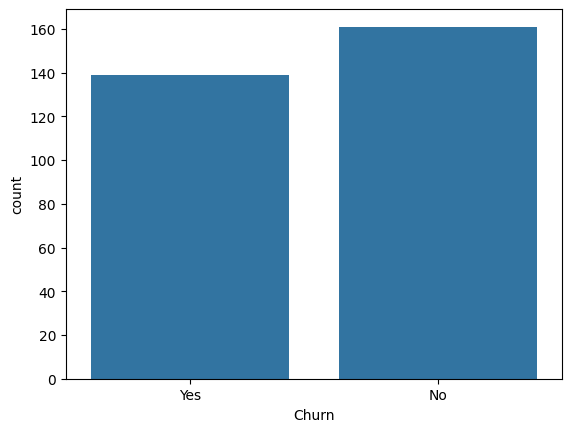

In [65]:
sns.countplot(x=df['Churn'])

In [66]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


<Axes: xlabel='tenure', ylabel='Count'>

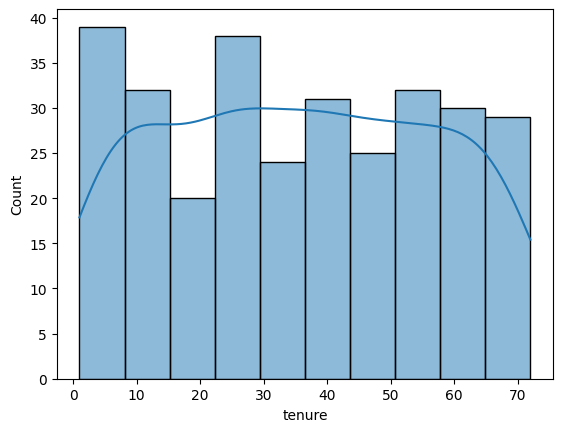

In [67]:
#Let's plot a histogram for skewneess
sns.histplot(df['tenure'],kde=True)

In [68]:
df['tenure'].skew()
#0  -> data centralized
#>0 -> Right skewed
#<0 -> Left Skewed

np.float64(0.02166595203393328)

In [69]:
df.drop(columns=['customerID'],inplace=True)

In [70]:
#One hot Encoding

#list honi chahiye jiske andar sirf 'object' data aaye
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [71]:
cat_cols.remove('Churn')

In [72]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [73]:
df_copy = pd.get_dummies(df,columns=cat_cols)

In [74]:
df_copy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,27.43,137.15,Yes,False,True,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,0,42,38.28,1607.76,Yes,True,False,True,False,True,...,False,False,False,True,True,False,False,False,True,False
2,0,61,106.44,6492.84,Yes,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
3,1,22,92.49,2034.78,No,False,True,True,False,False,...,True,True,False,False,True,False,False,False,True,False
4,1,21,19.63,412.23,Yes,False,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,61,42.52,2593.72,No,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
296,0,49,22.31,1093.19,Yes,True,False,True,False,True,...,True,True,False,False,False,True,False,False,False,True
297,0,71,59.57,4229.47,Yes,False,True,True,False,False,...,True,False,False,True,True,False,False,False,False,True
298,1,1,31.32,31.32,No,False,True,False,True,False,...,True,False,False,True,True,False,False,True,False,False


In [75]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy['Churn'] =  le.fit_transform(df['Churn'])

In [76]:
df_copy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,27.43,137.15,1,False,True,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,0,42,38.28,1607.76,1,True,False,True,False,True,...,False,False,False,True,True,False,False,False,True,False
2,0,61,106.44,6492.84,1,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
3,1,22,92.49,2034.78,0,False,True,True,False,False,...,True,True,False,False,True,False,False,False,True,False
4,1,21,19.63,412.23,1,False,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,61,42.52,2593.72,0,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
296,0,49,22.31,1093.19,1,True,False,True,False,True,...,True,True,False,False,False,True,False,False,False,True
297,0,71,59.57,4229.47,1,False,True,True,False,False,...,True,False,False,True,True,False,False,False,False,True
298,1,1,31.32,31.32,0,False,True,False,True,False,...,True,False,False,True,True,False,False,True,False,False


In [77]:
#Split X and y variables for model training and testing
X = df_copy.drop(columns=['Churn'])
y = df_copy['Churn']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
#building model

from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()


In [80]:
#training model
logistic.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [81]:
#prediction model
y_pred=logistic.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [82]:
#evaluate model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

#1. acuurancy_score
print(f"Acuurancy score for training {accuracy_score(y_test,y_pred)}")

Acuurancy score for training 0.4666666666666667


In [83]:
print(f"Acuurancy score for training {accuracy_score(y_train,logistic.predict(X_train))}")

Acuurancy score for training 0.6875


<Axes: >

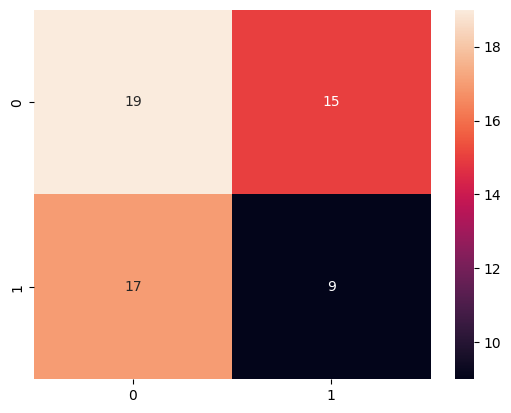

In [84]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [85]:
#importing the model to create  dashing ui
import joblib
joblib.dump(logistic,'logistic.pkl')

['logistic.pkl']